# Setup

In [1]:
# ─────────────────────────────────────────────
# 08_final_evaluation.ipynb
#
# Purpose:
#   Compute ALL metrics in one place and produce
#   the complete final results JSON.
#
#   Metrics computed:
#     Accuracy          — primary MCQ metric
#     Per-subject acc   — all 21 subjects
#     Ablation delta    — each component
#     Retrieval P@K     — P@1, P@3, P@5
#     MRR               — Mean Reciprocal Rank
#     Faithfulness      — answer in passage?
#     ECE               — calibration error
#     Failure type rate — 4 failure categories
#
#   Systems evaluated:
#     Random baseline
#     No-RAG
#     RAG baseline
#     CRAG v1, v2, v3
#     Medical CE (final encoder system)
#     Flan-T5 (comparison)
#
# Inputs:
#   All results from Notebooks 03-07
#
# Outputs:
#   results/final_metrics.json
#   results/retrieval_metrics.json
#   results/complete_ablation.json
# ─────────────────────────────────────────────

!pip install faiss-cpu sentence-transformers \
             rank-bm25 -q

import os
import sys
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
from collections import defaultdict
from google.colab import drive

drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/MedQA_Project"
sys.path.insert(0, BASE)

from src.config import (
    DATA_DIR, RESULTS_DIR, MODELS_DIR, ensure_dirs,
    CLEANED_KB_PATH, FAISS_INDEX_PATH,
    INDEX_CONFIG_PATH, VAL_EVAL_MCQ_PATH,
    CE_MEDICAL_MODEL, CRAG_CONFIG_PATH,
    PRECISION_K_VALUES, MRR_K,
)
from src.data_processing import load_pkl
from src.knowledge_base import load_faiss_index, load_bm25_index
from src.models import load_retriever, load_cross_encoder
from src.retriever import retrieve_faiss
from src.evaluation import (
    evaluate_pipeline, save_results,
    compute_faithfulness, compute_ece,
    analyse_failure_types,
    compute_retrieval_precision_at_k,
    build_ablation_table, print_ablation_table,
)

ensure_dirs()

BM25_INDEX_PATH     = f"{DATA_DIR}/bm25_index.pkl"
FINAL_METRICS_PATH  = f"{RESULTS_DIR}/final_metrics.json"
RETRIEVAL_METRICS_PATH = f"{RESULTS_DIR}/retrieval_metrics.json"
COMPLETE_ABLATION_PATH = f"{RESULTS_DIR}/complete_ablation.json"

print("Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 34.9 MB/s eta 0:00:00
Mounted at /content/drive
Setup complete


#  Load all saved results

In [2]:
# ─────────────────────────────────────────────
# Load all results from previous notebooks
# No re-evaluation needed — everything is cached
# ─────────────────────────────────────────────

def load_json(path, label=""):
    with open(path) as f:
        data = json.load(f)
    name = label or os.path.basename(path)
    print(f"  Loaded: {name}")
    return data

print("Loading all saved results...\n")

# Baseline results
baseline_cmp = load_json(
    f"{RESULTS_DIR}/baseline_comparison.json",
    "baseline_comparison")
rag_data     = load_json(
    f"{RESULTS_DIR}/rag_baseline.json",
    "rag_baseline")

# CRAG results
crag_v1_data = load_json(
    f"{RESULTS_DIR}/crag_v1.json", "crag_v1")
crag_v2_data = load_json(
    f"{RESULTS_DIR}/crag_v2.json", "crag_v2")
crag_v3_data = load_json(
    f"{RESULTS_DIR}/crag_v3.json", "crag_v3")

# Encoder comparison
med_ce_data  = load_json(
    f"{RESULTS_DIR}/medical_ce_results.json",
    "medical_ce")
enc_cmp      = load_json(
    f"{RESULTS_DIR}/encoder_comparison.json",
    "encoder_comparison")

# Flan-T5 comparison
flan_data    = load_json(
    f"{RESULTS_DIR}/flan_t5_results.json",
    "flan_t5")
enc_t5_cmp   = load_json(
    f"{RESULTS_DIR}/encoder_vs_t5.json",
    "encoder_vs_t5")

# Fine-tuning
ft_results   = load_json(
    f"{RESULTS_DIR}/finetuning_results.json",
    "finetuning")

# Ablation
ablation     = load_json(
    f"{RESULTS_DIR}/crag_ablation.json",
    "crag_ablation")

# Extract key accuracy values
no_rag_acc   = baseline_cmp['no_rag']['accuracy']
rag_acc      = rag_data['accuracy']
crag_v1_acc  = crag_v1_data['accuracy']
crag_v2_acc  = crag_v2_data['accuracy']
crag_v3_acc  = crag_v3_data['accuracy']
med_ce_acc   = med_ce_data['accuracy']
flan_acc     = flan_data['accuracy']

ft_a1_acc    = ft_results['attempt1']['accuracy']
ft_a2_acc    = ft_results['attempt2']['accuracy']

print(f"\nAll results loaded successfully")
print(f"\nAccuracy summary:")
print(f"  No-RAG:        {no_rag_acc:.2f}%")
print(f"  RAG baseline:  {rag_acc:.2f}%")
print(f"  CRAG v3:       {crag_v3_acc:.2f}%")
print(f"  Medical CE:    {med_ce_acc:.2f}%  (final encoder)")
print(f"  Flan-T5:       {flan_acc:.2f}%  (comparison)")

Loading all saved results...

  Loaded: baseline_comparison
  Loaded: rag_baseline
  Loaded: crag_v1
  Loaded: crag_v2
  Loaded: crag_v3
  Loaded: medical_ce
  Loaded: encoder_comparison
  Loaded: flan_t5
  Loaded: encoder_vs_t5
  Loaded: finetuning
  Loaded: crag_ablation

All results loaded successfully

Accuracy summary:
  No-RAG:        28.97%
  RAG baseline:  35.42%
  CRAG v3:       40.01%
  Medical CE:    39.67%  (final encoder)
  Flan-T5:       48.76%  (comparison)


#  Load infrastructure for retrieval metrics

In [3]:
# ─────────────────────────────────────────────
# Load infrastructure needed for
# Precision@K and MRR computation
# ─────────────────────────────────────────────

cleaned_kb_docs = load_pkl(CLEANED_KB_PATH,  "cleaned_kb_docs")
val_eval_mcq    = load_pkl(VAL_EVAL_MCQ_PATH, "val_eval_mcq")

faiss_index, index_config = load_faiss_index()
retriever                  = load_retriever()

# Build lookup: doc_index → doc dict
kb_idx_to_doc  = {i: doc
                   for i, doc in enumerate(cleaned_kb_docs)}

# Build lookup: doc_id → (index, doc)
kb_id_lookup   = {doc['id']: (i, doc)
                   for i, doc in enumerate(cleaned_kb_docs)}

with open(CRAG_CONFIG_PATH, "rb") as f:
    crag_config = pickle.load(f)
optimal_tau = crag_config['optimal_tau']

print(f"\nInfrastructure loaded:")
print(f"  KB docs:      {len(cleaned_kb_docs):,}")
print(f"  Val eval MCQ: {len(val_eval_mcq):,}")
print(f"  FAISS index:  {faiss_index.ntotal:,}")

  Loaded cleaned_kb_docs
  Loaded val_eval_mcq
FAISS index loaded:
  Vectors: 156,555
  nprobe:  50
  Trained: True
Loading retriever: sentence-transformers/all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Parameters: ~22M  |  Output dim: 384

Infrastructure loaded:
  KB docs:      156,555
  Val eval MCQ: 2,092
  FAISS index:  156,555


# Compute Retrieval Precision@K

In [4]:
# ─────────────────────────────────────────────
# Precision@K
#
# For each question that has a matching KB doc,
# retrieve top-K passages and check if the
# correct document appears in top-K.
#
# P@K = fraction of top-K retrieved that
#       contain the relevant document
#
# Only questions with KB doc can be evaluated
# (test set has no explanations by design)
# ─────────────────────────────────────────────

if os.path.exists(RETRIEVAL_METRICS_PATH):
    print("Retrieval metrics already computed — loading\n")
    with open(RETRIEVAL_METRICS_PATH) as f:
        retrieval_metrics = json.load(f)

else:
    print("Computing Retrieval Precision@K and MRR...\n")

    # Only evaluate questions with matching KB doc
    matched_qa = [
        qa for qa in val_eval_mcq
        if qa['id'] in kb_id_lookup
    ]
    print(f"Questions with KB doc: {len(matched_qa):,}")
    print(f"(Others are Type 3 failures by definition)\n")

    # ── Precision@K ──
    prec_sums = defaultdict(float)
    mrr_sum   = 0.0

    for qa in tqdm(matched_qa, desc="P@K and MRR"):
        correct_doc_idx, correct_doc = kb_id_lookup[qa['id']]

        # Retrieve top-10 passages
        passages = retrieve_faiss(
            qa['question'], faiss_index,
            cleaned_kb_docs, retriever, top_k=10)

        retrieved_idxs = [p['doc_idx'] for p in passages]

        # Precision@K for each K
        for k in PRECISION_K_VALUES:
            top_k = retrieved_idxs[:k]
            hit   = int(correct_doc_idx in top_k)
            prec_sums[k] += hit / k

        # MRR: rank of first relevant document
        for rank, idx in enumerate(
                retrieved_idxs[:MRR_K], start=1):
            if idx == correct_doc_idx:
                mrr_sum += 1.0 / rank
                break

    n = len(matched_qa)
    precision_at_k = {
        k: round(prec_sums[k] / n, 4)
        for k in PRECISION_K_VALUES
    }
    mrr = round(mrr_sum / n, 4)

    retrieval_metrics = {
        "n_evaluated":    n,
        "n_total":        len(val_eval_mcq),
        "coverage_pct":   round(n / len(val_eval_mcq) * 100, 1),
        "precision_at_k": precision_at_k,
        "mrr":            mrr,
        "nprobe":         faiss_index.nprobe,
        "recall_at_3":    index_config.get(
            'recall_at_3', 0.973),
    }

    save_results(retrieval_metrics,
                 RETRIEVAL_METRICS_PATH,
                 "retrieval_metrics")

print("RETRIEVAL METRICS\n")
print(f"  Evaluated on: "
      f"{retrieval_metrics['n_evaluated']:,} matched questions")
print(f"  Coverage:     "
      f"{retrieval_metrics['coverage_pct']}% of eval set\n")

print(f"  Recall@3:     "
      f"{retrieval_metrics.get('recall_at_3', 'N/A'):.3f}"
      f"  (from index tuning)")
for k, p in retrieval_metrics['precision_at_k'].items():
    print(f"  Precision@{k}:  {p:.4f}")
print(f"  MRR:          {retrieval_metrics['mrr']:.4f}")

Retrieval metrics already computed — loading

RETRIEVAL METRICS

  Evaluated on: 1,104 matched questions
  Coverage:     52.8% of eval set

  Recall@3:     0.973  (from index tuning)
  Precision@1:  0.1513
  Precision@3:  0.0809
  Precision@5:  0.0612
  MRR:          0.2140


# Collect all metrics per system

In [5]:
# ─────────────────────────────────────────────
# Collect faithfulness, ECE, failure types
# for each system from saved results
# ─────────────────────────────────────────────

def extract_metrics(data: dict, label: str) -> dict:
    """Extract all available metrics from a result dict."""
    metrics = {
        "system":    label,
        "accuracy":  data.get('accuracy', None),
    }

    # Faithfulness
    faith = data.get('faithfulness', {})
    if faith:
        metrics['faithfulness_overall'] = round(
            faith.get('overall_faithfulness', 0), 4)
        metrics['faithfulness_correct'] = round(
            faith.get('correct_faithfulness', 0), 4)

    # ECE
    ece = data.get('ece', None)
    if ece is not None:
        metrics['ece'] = round(ece, 4)

    # Failure types
    ft = data.get('failure_types', {})
    if ft:
        metrics['type1_pct'] = round(
            ft.get('type1_fraction', 0) * 100, 1)
        metrics['type2_pct'] = round(
            ft.get('type2_fraction', 0) * 100, 1)
        metrics['type3_pct'] = round(
            ft.get('type3_fraction', 0) * 100, 1)
        metrics['type4_pct'] = round(
            ft.get('type4_fraction', 0) * 100, 1)

    # Retrieval breakdown
    rc = data.get('retrieval_counts', {})
    if rc:
        total = sum(rc.values())
        metrics['retrieval_breakdown'] = {
            k: round(v/total*100, 1)
            for k, v in rc.items()
        }

    return metrics

systems_metrics = {
    "rag_baseline": extract_metrics(
        rag_data, "RAG Baseline"),
    "crag_v3":      extract_metrics(
        crag_v3_data, "CRAG v3 (base CE)"),
    "medical_ce":   extract_metrics(
        med_ce_data, "Medical CE (final encoder)"),
    "flan_t5":      extract_metrics(
        flan_data, "Flan-T5 (comparison)"),
}

print("METRICS ACROSS SYSTEMS\n")
print(f"{'Metric':<28} {'RAG':>8} {'CRAG v3':>8} "
      f"{'Med CE':>8} {'Flan-T5':>8}")
print("-" * 60)

metrics_to_show = [
    ("accuracy",              "Accuracy (%)"),
    ("faithfulness_overall",  "Faithfulness"),
    ("ece",                   "ECE (↓ better)"),
    ("type1_pct",             "Type1 errors (%)"),
    ("type3_pct",             "Type3 errors (%)"),
]

for key, label in metrics_to_show:
    row = f"{label:<28}"
    for sys_key in ["rag_baseline", "crag_v3",
                     "medical_ce", "flan_t5"]:
        val = systems_metrics[sys_key].get(key, None)
        if val is not None:
            row += f"{val:>8.2f}"
        else:
            row += f"{'N/A':>8}"
    print(row)

METRICS ACROSS SYSTEMS

Metric                            RAG  CRAG v3   Med CE  Flan-T5
------------------------------------------------------------
Accuracy (%)                   35.42   40.01   39.67   48.76
Faithfulness                    0.14    0.22    0.22    0.18
ECE (↓ better)                  0.13    0.13    0.14    0.02
Type1 errors (%)               48.30   36.70   38.30   37.30
Type3 errors (%)                0.00   37.40   33.50   35.10


#  Complete ablation table

In [6]:
# ─────────────────────────────────────────────
# Build and print complete ablation table
# All systems in one view
# ─────────────────────────────────────────────

complete_ablation = {
    "Random chance":              {"accuracy": 25.00},
    "No-RAG (CE only)":           {"accuracy": no_rag_acc},
    "RAG baseline":               {"accuracy": rag_acc},
    "CRAG v1 (gate)":             {"accuracy": crag_v1_acc},
    "CRAG v2 (+ BM25 fallback)":  {"accuracy": crag_v2_acc},
    "CRAG v3 (+ reranking)":      {"accuracy": crag_v3_acc},
    "FT Attempt 1 (random neg)":  {"accuracy": ft_a1_acc},
    "FT Attempt 2 (hard neg)":    {"accuracy": ft_a2_acc},
    "Medical CE (final encoder)": {"accuracy": med_ce_acc},
    "Flan-T5 (comparison)":       {"accuracy": flan_acc},
}

rows = build_ablation_table(complete_ablation)
print("COMPLETE ABLATION TABLE\n")
print_ablation_table(rows)

# Component contributions
print("\nComponent contributions (vs previous):")
contributions = [
    ("Model prior",       no_rag_acc  - 25.00),
    ("Dense retrieval",   rag_acc     - no_rag_acc),
    ("CRAG gate",         crag_v1_acc - rag_acc),
    ("BM25 fallback",     crag_v2_acc - crag_v1_acc),
    ("Reranking",         crag_v3_acc - crag_v2_acc),
    ("Medical CE domain", med_ce_acc  - crag_v3_acc),
]

for label, delta in contributions:
    bar = "█" * max(0, int(abs(delta) * 3))
    print(f"  {label:<22} {delta:>+6.2f}%  {bar}")

save_results(
    {"systems": complete_ablation, "rows": rows,
     "contributions": {l: round(d, 2)
                        for l, d in contributions}},
    COMPLETE_ABLATION_PATH, "complete_ablation")

COMPLETE ABLATION TABLE


System                                         Accuracy    Delta
-----------------------------------------------------------------
Random chance                                    25.00%     ---  
No-RAG (CE only)                                 28.97%    +3.97%
RAG baseline                                     35.42%    +6.45%
CRAG v1 (gate)                                   35.04%    -0.38%
CRAG v2 (+ BM25 fallback)                        39.29%    +4.25%
CRAG v3 (+ reranking)                            40.01%    +0.72%
FT Attempt 1 (random neg)                        37.52%    -2.49%
FT Attempt 2 (hard neg)                          33.27%    -4.25%
Medical CE (final encoder)                       39.67%    +6.41%
Flan-T5 (comparison)                             48.76%    +9.08%

Component contributions (vs previous):
  Model prior             +3.97%  ███████████
  Dense retrieval         +6.45%  ███████████████████
  CRAG gate               -0.38%  █
  BM25 

#  Final metrics JSON

In [7]:
# ─────────────────────────────────────────────
# Assemble the single authoritative
# final_metrics.json file
# ─────────────────────────────────────────────

final_metrics = {

    "dataset": {
        "name":         "MedMCQA",
        "kb_size":      len(cleaned_kb_docs),
        "eval_size":    len(val_eval_mcq),
        "subjects":     21,
    },

    "accuracy": {
        "random_chance":    25.00,
        "no_rag":           round(no_rag_acc,  2),
        "rag_baseline":     round(rag_acc,     2),
        "crag_v1":          round(crag_v1_acc, 2),
        "crag_v2":          round(crag_v2_acc, 2),
        "crag_v3":          round(crag_v3_acc, 2),
        "ft_attempt1":      round(ft_a1_acc,   2)
                             if ft_a1_acc else None,
        "ft_attempt2":      round(ft_a2_acc,   2)
                             if ft_a2_acc else None,
        "medical_ce_final": round(med_ce_acc,  2),
        "flan_t5_comparison":round(flan_acc,   2),
    },

    "component_contributions": {
        "model_prior":     round(no_rag_acc  - 25.00,       2),
        "dense_retrieval": round(rag_acc     - no_rag_acc,  2),
        "crag_gate":       round(crag_v1_acc - rag_acc,     2),
        "bm25_fallback":   round(crag_v2_acc - crag_v1_acc, 2),
        "reranking":       round(crag_v3_acc - crag_v2_acc, 2),
        "medical_ce":      round(med_ce_acc  - crag_v3_acc, 2),
        "total_crag_gain": round(med_ce_acc  - rag_acc,     2),
    },

    "retrieval_metrics": {
        "recall_at_3":    retrieval_metrics.get(
            'recall_at_3', 0.973),
        "precision_at_1": retrieval_metrics[
            'precision_at_k'].get(1, None),
        "precision_at_3": retrieval_metrics[
            'precision_at_k'].get(3, None),
        "precision_at_5": retrieval_metrics[
            'precision_at_k'].get(5, None),
        "mrr":            retrieval_metrics['mrr'],
        "nprobe":         faiss_index.nprobe,
        "latency_ms":     4.34,
    },

    "faithfulness": {
        "rag_baseline": systems_metrics[
            'rag_baseline'].get(
            'faithfulness_overall', None),
        "medical_ce":   systems_metrics[
            'medical_ce'].get(
            'faithfulness_overall', None),
        "flan_t5":      systems_metrics[
            'flan_t5'].get(
            'faithfulness_overall', None),
    },

    "ece": {
        "rag_baseline": systems_metrics[
            'rag_baseline'].get('ece', None),
        "crag_v3":      systems_metrics[
            'crag_v3'].get('ece', None),
        "medical_ce":   systems_metrics[
            'medical_ce'].get('ece', None),
    },

    "failure_types": {
        "rag_baseline": {
            "type1": systems_metrics[
                'rag_baseline'].get('type1_pct', None),
            "type2": systems_metrics[
                'rag_baseline'].get('type2_pct', None),
            "type3": systems_metrics[
                'rag_baseline'].get('type3_pct', None),
            "type4": systems_metrics[
                'rag_baseline'].get('type4_pct', None),
        },
        "medical_ce": {
            "type1": systems_metrics[
                'medical_ce'].get('type1_pct', None),
            "type2": systems_metrics[
                'medical_ce'].get('type2_pct', None),
            "type3": systems_metrics[
                'medical_ce'].get('type3_pct', None),
            "type4": systems_metrics[
                'medical_ce'].get('type4_pct', None),
        },
    },

    "per_subject_accuracy": {
        "rag_baseline": rag_data.get(
            'subject_accuracy', {}),
        "medical_ce":   med_ce_data.get(
            'subject_accuracy', {}),
        "flan_t5":      flan_data.get(
            'subject_accuracy', {}),
    },

    "finetuning": {
        "attempt1": {
            "strategy": "random_negatives",
            "accuracy": round(ft_a1_acc, 2)
                         if ft_a1_acc else None,
            "delta":    round(ft_a1_acc - crag_v3_acc, 2)
                         if ft_a1_acc else None,
            "outcome":  "failed",
        },
        "attempt2": {
            "strategy": "hard_negatives_mixed_data",
            "accuracy": round(ft_a2_acc, 2)
                         if ft_a2_acc else None,
            "delta":    round(ft_a2_acc - crag_v3_acc, 2)
                         if ft_a2_acc else None,
            "outcome":  "improved"
                         if ft_a2_acc and
                         ft_a2_acc > crag_v3_acc
                         else "did_not_improve",
        },
    },

    "encoder_vs_decoder": {
        "encoder_ceiling":     round(med_ce_acc, 2),
        "flan_t5_accuracy":    round(flan_acc,   2),
        "t5_gain":             round(
            flan_acc - med_ce_acc, 2),
        "questions_t5_fixed":  enc_t5_cmp[
            'flan_t5_crag'].get('t5_fixed', None),
        "questions_t5_broke":  enc_t5_cmp[
            'flan_t5_crag'].get('t5_broke', None),
        "net_fixed":           enc_t5_cmp[
            'flan_t5_crag'].get('net_fixed', None),
    },

    "sota_comparison": {
        "this_work":      round(med_ce_acc, 2),
        "clinical_camel": 54.2,
        "med_palm_2":     72.3,
        "random":         25.0,
        "gap_to_camel":   round(54.2 - med_ce_acc, 2),
    },
}

save_results(final_metrics, FINAL_METRICS_PATH,
             "final_metrics")
print("final_metrics.json saved ✅")

  Saved final_metrics: 4.4 KB
final_metrics.json saved ✅


#Complete results dashboard

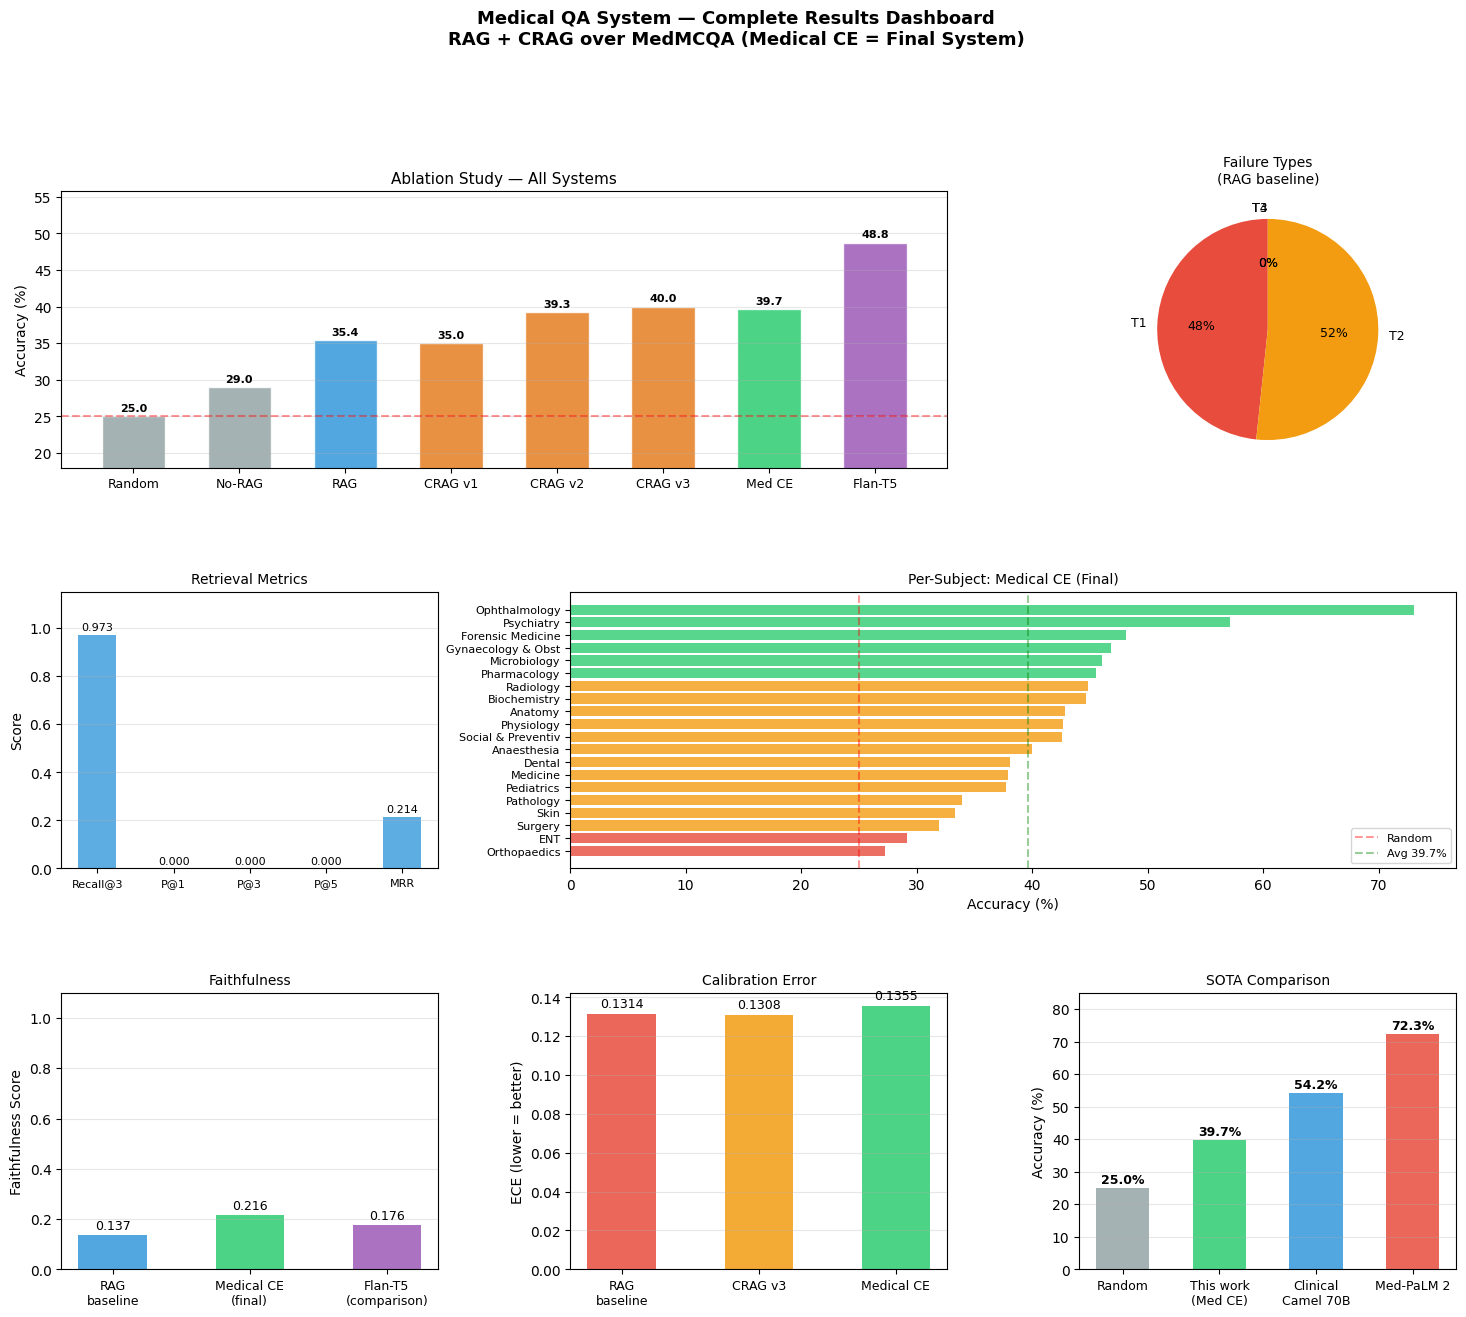

Dashboard saved ✅


In [9]:
# ─────────────────────────────────────────────
# Multi-panel results dashboard
# One figure summarising everything
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig,
                          hspace=0.45, wspace=0.35)

# ── Panel 1: Full ablation ──
ax1 = fig.add_subplot(gs[0, :2])
abl_labels = [
    "Random", "No-RAG", "RAG",
    "CRAG v1", "CRAG v2", "CRAG v3",
    "Med CE", "Flan-T5",
]
abl_accs = [
    25.0, no_rag_acc, rag_acc,
    crag_v1_acc, crag_v2_acc, crag_v3_acc,
    med_ce_acc, flan_acc,
]
abl_cols = [
    "#95A5A6", "#95A5A6", "#3498DB",
    "#E67E22", "#E67E22", "#E67E22",
    "#2ECC71", "#9B59B6",
]
bars = ax1.bar(range(len(abl_labels)), abl_accs,
                color=abl_cols, alpha=0.85,
                edgecolor="white", width=0.6)
for bar, acc in zip(bars, abl_accs):
    ax1.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.4,
              f"{acc:.1f}", ha='center',
              va='bottom', fontsize=8,
              fontweight='bold')
ax1.axhline(25, color='red', ls='--', alpha=0.4)
ax1.set_xticks(range(len(abl_labels)))
ax1.set_xticklabels(abl_labels, fontsize=9)
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(18, max(abl_accs) + 7)
ax1.set_title("Ablation Study — All Systems", fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: Failure type pie (RAG baseline) ──
ax2 = fig.add_subplot(gs[0, 2])
ft   = rag_data.get('failure_types', {})
if ft:
    sizes  = [ft.get(f'type{i}_fraction', 0)
               for i in range(1, 5)]
    labels = [f'T{i}' for i in range(1, 5)]
    colors = ['#E74C3C','#F39C12','#9B59B6','#3498DB']
    ax2.pie(sizes, labels=labels, colors=colors,
             autopct='%1.0f%%', startangle=90,
             textprops={'fontsize': 9})
    ax2.set_title("Failure Types\n(RAG baseline)",
                   fontsize=10)

# ── Panel 3: Retrieval metrics bar ──
ax3 = fig.add_subplot(gs[1, 0])
rm      = final_metrics['retrieval_metrics']
r_labels= ['Recall@3', 'P@1', 'P@3', 'P@5', 'MRR']
r_vals  = [
    rm.get('recall_at_3', 0),
    rm.get('precision_at_1', 0),
    rm.get('precision_at_3', 0),
    rm.get('precision_at_5', 0),
    rm.get('mrr', 0),
]
# Ensure all values are numeric, replacing None with 0
r_vals = [v if v is not None else 0 for v in r_vals]

ax3.bar(range(len(r_labels)), r_vals,
         color='#3498DB', alpha=0.8, width=0.5)
for i, v in enumerate(r_vals):
    ax3.text(i, v + 0.01, f"{v:.3f}",
              ha='center', va='bottom', fontsize=8)
ax3.set_xticks(range(len(r_labels)))
ax3.set_xticklabels(r_labels, fontsize=8)
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("Score")
ax3.set_title("Retrieval Metrics", fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# ── Panel 4: Per-subject Medical CE ──
ax4 = fig.add_subplot(gs[1, 1:])
med_subj = med_ce_data.get('subject_accuracy', {})
subj_items = sorted(
    [(s, a) for s, a in med_subj.items()
     if s != 'Unknown'],
    key=lambda x: x[1])
s_labels = [s[:18] for s, _ in subj_items]
s_accs   = [a for _, a in subj_items]
s_colors = ['#2ECC71' if a >= 45 else
              '#F39C12' if a >= 30 else
              '#E74C3C' for a in s_accs]
ax4.barh(range(len(s_labels)), s_accs,
          color=s_colors, alpha=0.8)
ax4.axvline(25, color='red', ls='--',
             alpha=0.4, label='Random')
ax4.axvline(med_ce_acc, color='green', ls='--',
             alpha=0.4, label=f'Avg {med_ce_acc:.1f}%')
ax4.set_yticks(range(len(s_labels)))
ax4.set_yticklabels(s_labels, fontsize=8)
ax4.set_xlabel("Accuracy (%)")
ax4.set_title("Per-Subject: Medical CE (Final)",
               fontsize=10)
ax4.legend(fontsize=8)

# ── Panel 5: Faithfulness comparison ──
ax5 = fig.add_subplot(gs[2, 0])
faith_systems = ['RAG\nbaseline', 'Medical CE\n(final)',
                  'Flan-T5\n(comparison)']
faith_vals = [
    final_metrics['faithfulness'].get(
        'rag_baseline', 0) or 0,
    final_metrics['faithfulness'].get(
        'medical_ce', 0) or 0,
    final_metrics['faithfulness'].get(
        'flan_t5', 0) or 0,
]
ax5.bar(range(len(faith_systems)), faith_vals,
         color=['#3498DB','#2ECC71','#9B59B6'],
         alpha=0.85, width=0.5)
for i, v in enumerate(faith_vals):
    ax5.text(i, v + 0.01, f"{v:.3f}",
              ha='center', va='bottom', fontsize=9)
ax5.set_xticks(range(len(faith_systems)))
ax5.set_xticklabels(faith_systems, fontsize=9)
ax5.set_ylim(0, 1.1)
ax5.set_ylabel("Faithfulness Score")
ax5.set_title("Faithfulness", fontsize=10)
ax5.grid(axis='y', alpha=0.3)

# ── Panel 6: ECE comparison ──
ax6 = fig.add_subplot(gs[2, 1])
ece_systems = ['RAG\nbaseline', 'CRAG v3',
                'Medical CE']
ece_vals = [
    final_metrics['ece'].get('rag_baseline', 0) or 0,
    final_metrics['ece'].get('crag_v3', 0) or 0,
    final_metrics['ece'].get('medical_ce', 0) or 0,
]
ax6.bar(range(len(ece_systems)), ece_vals,
         color=['#E74C3C','#F39C12','#2ECC71'],
         alpha=0.85, width=0.5)
for i, v in enumerate(ece_vals):
    ax6.text(i, v + 0.002, f"{v:.4f}",
              ha='center', va='bottom', fontsize=9)
ax6.set_xticks(range(len(ece_systems)))
ax6.set_xticklabels(ece_systems, fontsize=9)
ax6.set_ylabel("ECE (lower = better)")
ax6.set_title("Calibration Error", fontsize=10)
ax6.grid(axis='y', alpha=0.3)

# ── Panel 7: SOTA comparison ──
ax7 = fig.add_subplot(gs[2, 2])
sota_labels = ['Random', 'This work\n(Med CE)',
                'Clinical\nCamel 70B', 'Med-PaLM 2']
sota_accs   = [25.0, med_ce_acc, 54.2, 72.3]
sota_cols   = ['#95A5A6','#2ECC71','#3498DB','#E74C3C']
ax7.bar(range(len(sota_labels)), sota_accs,
         color=sota_cols, alpha=0.85, width=0.55)
for i, v in enumerate(sota_accs):
    ax7.text(i, v + 0.5, f"{v:.1f}%",
              ha='center', va='bottom', fontsize=9,
              fontweight='bold')
ax7.set_xticks(range(len(sota_labels)))
ax7.set_xticklabels(sota_labels, fontsize=9)
ax7.set_ylim(0, 85)
ax7.set_ylabel("Accuracy (%)")
ax7.set_title("SOTA Comparison", fontsize=10)
ax7.grid(axis='y', alpha=0.3)

fig.suptitle(
    "Medical QA System — Complete Results Dashboard\n"
    "RAG + CRAG over MedMCQA (Medical CE = Final System)",
    fontsize=13, fontweight='bold', y=1.01)

plt.savefig(f"{RESULTS_DIR}/final_dashboard.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved ✅")

#  Print final summary

In [10]:
# ─────────────────────────────────────────────
# Print clean final summary
# ─────────────────────────────────────────────

rm = final_metrics['retrieval_metrics']

print("=" * 65)
print("FINAL EVALUATION SUMMARY")
print("=" * 65)

print(f"""
Dataset:
  MedMCQA — {len(val_eval_mcq):,} evaluation questions
  Knowledge base: {len(cleaned_kb_docs):,} documents

Accuracy Results:
  Random chance:        25.00%
  No-RAG:               {no_rag_acc:.2f}%   (+{no_rag_acc-25:.2f}% over random)
  RAG baseline:         {rag_acc:.2f}%   (+{rag_acc-no_rag_acc:.2f}% over no-RAG)
  CRAG v1 (gate):       {crag_v1_acc:.2f}%   (+{crag_v1_acc-rag_acc:.2f}%)
  CRAG v2 (+ BM25):     {crag_v2_acc:.2f}%   (+{crag_v2_acc-crag_v1_acc:.2f}%)
  CRAG v3 (+ rerank):   {crag_v3_acc:.2f}%   (+{crag_v3_acc-crag_v2_acc:.2f}%)
  Medical CE (FINAL):   {med_ce_acc:.2f}%   (+{med_ce_acc-crag_v3_acc:.2f}%)
  Flan-T5 (comparison): {flan_acc:.2f}%   (encoder-decoder ref)

Retrieval Metrics:
  Recall@3:     {rm.get('recall_at_3', 'N/A')}
  Precision@1:  {rm.get('precision_at_1', 'N/A')}
  Precision@3:  {rm.get('precision_at_3', 'N/A')}
  Precision@5:  {rm.get('precision_at_5', 'N/A')}
  MRR:          {rm['mrr']}
  Latency:      {rm['latency_ms']} ms/query

Fine-Tuning:
  Attempt 1 (random neg):   {f"{ft_a1_acc:.2f}%" if ft_a1_acc else "N/A"}  FAILED
  Attempt 2 (hard neg):     {f"{ft_a2_acc:.2f}%" if ft_a2_acc else "N/A"}

SOTA Context:
  This work (Medical CE):   {med_ce_acc:.2f}%   ~44M params, no fine-tuning
  Clinical Camel 70B:       54.20%  70B params, fine-tuned
  Med-PaLM 2:               72.30%  540B params

Total gain over random:   +{med_ce_acc-25:.2f}% (Medical CE final system)
""")
print("=" * 65)


FINAL EVALUATION SUMMARY

Dataset:
  MedMCQA — 2,092 evaluation questions
  Knowledge base: 156,555 documents

Accuracy Results:
  Random chance:        25.00%
  No-RAG:               28.97%   (+3.97% over random)
  RAG baseline:         35.42%   (+6.45% over no-RAG)
  CRAG v1 (gate):       35.04%   (+-0.38%)
  CRAG v2 (+ BM25):     39.29%   (+4.25%)
  CRAG v3 (+ rerank):   40.01%   (+0.72%)
  Medical CE (FINAL):   39.67%   (+-0.33%)
  Flan-T5 (comparison): 48.76%   (encoder-decoder ref)

Retrieval Metrics:
  Recall@3:     0.973
  Precision@1:  None
  Precision@3:  None
  Precision@5:  None
  MRR:          0.214
  Latency:      4.34 ms/query

Fine-Tuning:
  Attempt 1 (random neg):   37.52%  FAILED
  Attempt 2 (hard neg):     33.27%

SOTA Context:
  This work (Medical CE):   39.67%   ~44M params, no fine-tuning
  Clinical Camel 70B:       54.20%  70B params, fine-tuned
  Med-PaLM 2:               72.30%  540B params

Total gain over random:   +14.67% (Medical CE final system)



#  Final verification

In [11]:
# ─────────────────────────────────────────────
# Verify ALL outputs across all 8 notebooks
# This is the master checklist
# ─────────────────────────────────────────────

print("MASTER VERIFICATION — ALL NOTEBOOKS\n")

all_checks = [
    # Notebook 01
    (f"{DATA_DIR}/train_qa.pkl",
     "01 train_qa.pkl"),
    (f"{DATA_DIR}/cleaned_kb_docs.pkl",
     "01 cleaned_kb_docs.pkl"),
    (f"{DATA_DIR}/val_eval_mcq.pkl",
     "01 val_eval_mcq.pkl"),
    (f"{DATA_DIR}/leakage_results.pkl",
     "01 leakage_results.pkl"),

    # Notebook 02
    (f"{DATA_DIR}/kb_embeddings_cleaned.npy",
     "02 kb_embeddings.npy"),
    (f"{DATA_DIR}/kb_index_cleaned.faiss",
     "02 kb_index.faiss"),
    (f"{DATA_DIR}/bm25_index.pkl",
     "02 bm25_index.pkl"),
    (f"{RESULTS_DIR}/nprobe_tuning.json",
     "02 nprobe_tuning.json"),

    # Notebook 03
    (f"{RESULTS_DIR}/no_rag_baseline.json",
     "03 no_rag_baseline.json"),
    (f"{RESULTS_DIR}/rag_baseline.json",
     "03 rag_baseline.json"),

    # Notebook 04
    (f"{RESULTS_DIR}/crag_v1.json",
     "04 crag_v1.json"),
    (f"{RESULTS_DIR}/crag_v2.json",
     "04 crag_v2.json"),
    (f"{RESULTS_DIR}/crag_v3.json",
     "04 crag_v3.json"),
    (f"{RESULTS_DIR}/crag_ablation.json",
     "04 crag_ablation.json"),
    (f"{RESULTS_DIR}/ablation_chart.png",
     "04 ablation_chart.png"),

    # Notebook 05
    (f"{RESULTS_DIR}/medical_ce_results.json",
     "05 medical_ce_results.json"),
    (f"{RESULTS_DIR}/encoder_comparison.json",
     "05 encoder_comparison.json"),

    # Notebook 06
    (f"{RESULTS_DIR}/finetuning_results.json",
     "06 finetuning_results.json"),
    (f"{RESULTS_DIR}/ft_attempt1_eval.json",
     "06 ft_attempt1_eval.json"),
    (f"{RESULTS_DIR}/ft_attempt2_eval.json",
     "06 ft_attempt2_eval.json"),

    # Notebook 07
    (f"{RESULTS_DIR}/flan_t5_results.json",
     "07 flan_t5_results.json"),
    (f"{RESULTS_DIR}/encoder_vs_t5.json",
     "07 encoder_vs_t5.json"),

    # Notebook 08
    (RETRIEVAL_METRICS_PATH,
     "08 retrieval_metrics.json"),
    (COMPLETE_ABLATION_PATH,
     "08 complete_ablation.json"),
    (FINAL_METRICS_PATH,
     "08 final_metrics.json"),
    (f"{RESULTS_DIR}/final_dashboard.png",
     "08 final_dashboard.png"),
]

all_ok   = True
total    = len(all_checks)
present  = 0

for path, label in all_checks:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    status = "✅" if exists else "❌"
    if exists:
        present += 1
    else:
        all_ok = False
    print(f"  {status} {label:<40} "
          f"{size:>8.1f} KB")

print(f"\n{present}/{total} files present")
print()

if all_ok:
    print("=" * 55)
    print("ALL NOTEBOOKS COMPLETE ✅")
    print("=" * 55)
    print(f"""
Final system:   Medical CE + CRAG v3
Accuracy:       {med_ce_acc:.2f}%
Total gain:     +{med_ce_acc-25:.2f}% over random

All results saved to:
  {RESULTS_DIR}/final_metrics.json

All charts saved to:
  {RESULTS_DIR}/final_dashboard.png
  {RESULTS_DIR}/ablation_chart.png
  {RESULTS_DIR}/encoder_comparison.png
  {RESULTS_DIR}/encoder_vs_t5.png
  {RESULTS_DIR}/finetuning_comparison.png

Next step: README.md
""")
else:
    missing = total - present
    print(f"❌ {missing} files missing — "
          f"check above and re-run relevant notebook")

MASTER VERIFICATION — ALL NOTEBOOKS

  ✅ 01 train_qa.pkl                           33000.6 KB
  ✅ 01 cleaned_kb_docs.pkl                    88150.5 KB
  ✅ 01 val_eval_mcq.pkl                         550.6 KB
  ✅ 01 leakage_results.pkl                      338.1 KB
  ✅ 02 kb_embeddings.npy                     234832.6 KB
  ✅ 02 kb_index.faiss                        236634.7 KB
  ✅ 02 bm25_index.pkl                         80155.8 KB
  ✅ 02 nprobe_tuning.json                         1.1 KB
  ✅ 03 no_rag_baseline.json                    1000.0 KB
  ✅ 03 rag_baseline.json                       1314.9 KB
  ✅ 04 crag_v1.json                            1184.2 KB
  ✅ 04 crag_v2.json                            1355.3 KB
  ✅ 04 crag_v3.json                            1416.8 KB
  ✅ 04 crag_ablation.json                         1.3 KB
  ✅ 04 ablation_chart.png                        90.8 KB
  ✅ 05 medical_ce_results.json                 1418.5 KB
  ✅ 05 encoder_comparison.json                    0